### Configuration

This notebook reads MongoDB credentials from the `MONGO_URI` environment variable. Set it before launching Jupyter and do not paste credentials into notebook cells.


In [ ]:
import os

mongo_uri = os.environ.get("MONGO_URI")
if not mongo_uri:
    raise RuntimeError("Set MONGO_URI before running this notebook.")

from episcope.db.mongo_academic_db import MongoAcademicDB
strategy_name="grobid"
db = MongoAcademicDB(
    uri=mongo_uri,
    db_name="episcope_academic_db",
)
len(db.list_docs(strategy_name=strategy_name))

In [ ]:
from episcope.vectordb.qdrant import QdrantDB
vdb = QdrantDB(
    collection="episcope_academic_vdb2", 
    # dim=emb.dim, 
    url="http://localhost:6334")

In [ ]:
import pandas as pd
df = pd.read_csv("sampled_papers_updated.csv", sep=";")
all_docs = df.paper_id.tolist()

In [ ]:
# all_docs = db.list_docs(strategy_name=strategy_name)

In [ ]:
from episcope.rag.retrieval.semantic import SemanticRetriever
retriever = SemanticRetriever(vdb)

In [ ]:
# from episcope.rag.generation.llm_generator import LLMGenerator
# generator = LLMGenerator(model="qwen2.5vl:3b") # "qwen2.5vl:3b"

from episcope.clients import GeminiClient
from episcope.rag.generation.llm_generator import LLMGenerator
client = GeminiClient()
generator = LLMGenerator(client=client, model="gemini-2.5-flash")

In [ ]:
from episcope.workflows import PaperClassifier
from episcope.workflows.classification import GeoClassifierConfig
classifier = PaperClassifier(
    retriever=retriever,
    generator=generator,
    academic_db=db,
    strategy_name=strategy_name,
    config=GeoClassifierConfig()
)

In [ ]:
classifier.run('10.4324/9780203506752-9')

In [ ]:
# import pandas as pd
# df_results_disk = pd.read_csv("GEO_samplev3.csv",sep=";")

In [ ]:
import pandas as pd
list_results = []

for paper_id in all_docs:
    # if paper_id in df_results_disk.paper_id.unique():
    #     print(f"skipping paper {paper_id} because it has already been analyzed")
    #     continue
    print(f"analyzing paper {paper_id}")
    c_res = classifier.run(paper_id)

    result = {
    "paper_id": paper_id,
    "classification": [c.name for c in c_res.classification],
    "class_probabilities": c_res.class_probabilities,
    "confidence": c_res.confidence,
    "evidence": c_res.evidence["reasoning"],
    "countries":c_res.extras["countries"] ,
    "cities": c_res.extras["cities"]
    }

    list_results.append(result)




In [ ]:
pd.set_option('display.max_colwidth', None)


df_results = pd.DataFrame(list_results)
# df_results

In [ ]:
df_results.to_csv("GEO_C4.csv", index=False,sep=";")

In [ ]:
df_results_new = pd.concat([df_results_disk,df_results])
len(df_results_new)

In [ ]:
# save df_results on disk
df_results_new.to_csv("GEO_3.csv")

In [ ]:
# df_results.to_csv("CLASSIFICATION_MODEL_NO_SNIPPETS.csv", index=False)

In [ ]:
# c_res.confidence

## Analysis

In [4]:
import pandas as pd
df_analysis = pd.read_csv("output_full/geo/gemini-2-5-flash/temperature_0.0/grobid/episcope-academic-vdb2-bc69ea5d6dad/final_1.tsv",index_col=False, sep="\t")
print(len(df_analysis))
df_analysis = df_analysis[["failed" not in txt_evidence for txt_evidence in df_analysis['evidence'].values]]
print(len(df_analysis))

2297
2297


In [ ]:
# pd.set_option('display.max_colwidth', None)
# df_analysis[df_analysis['classification'].apply(lambda x: "UNCLEAR" in eval(x))]

In [2]:
df_analysis.columns

Index(['paper_id', 'classification', 'class_probabilities', 'confidence',
       'evidence', 'countries', 'cities', 'extras'],
      dtype='object')

In [5]:
from collections import Counter
c_city = Counter([city for city_list in df_analysis.cities.values for city in eval(city_list)])
c_city.most_common(10)

[('Wuhan', 192),
 ('West Africa', 85),
 ('Hong Kong', 54),
 ('Hubei Province', 52),
 ('Hubei province', 37),
 ('Hubei', 36),
 ('Beijing', 32),
 ('Middle East', 30),
 ('London', 29),
 ('Ankara', 24)]

In [6]:
from collections import Counter

c_city = Counter([country for countries_list in df_analysis.countries.values for country in eval(countries_list)])
c_city.most_common(10)



[('China', 403),
 ('United States', 167),
 ('Nigeria', 148),
 ('Turkey', 140),
 ('France', 126),
 ('Sierra Leone', 125),
 ('Iran', 124),
 ('Germany', 109),
 ('Italy', 109),
 ('South Africa', 106)]

In [7]:
n_papers = len(df_analysis)

In [8]:
n_papers 

2297

In [ ]:
# df_analysis.classification.values

In [9]:
entries = [data_type for data_types_list in df_analysis.classification.values for data_type in eval(data_types_list)]

In [12]:
from collections import Counter
c = Counter(entries)
c

Counter({'ASIA': 1058,
         'AFRICA': 870,
         'EUROPE': 604,
         'NORTH_AMERICA': 433,
         'SOUTH_AMERICA': 228,
         'OCEANIA': 192,
         'IRRELEVANT': 75,
         'UNCLEAR': 53})

In [13]:
c_frac = {k:v/n_papers for k,v in c.items()}

In [14]:
c_frac

{'AFRICA': 0.3787548976926426,
 'ASIA': 0.4606007836308228,
 'EUROPE': 0.2629516760992599,
 'NORTH_AMERICA': 0.18850674793208533,
 'SOUTH_AMERICA': 0.09925990422289943,
 'OCEANIA': 0.08358728776665215,
 'IRRELEVANT': 0.032651284283848496,
 'UNCLEAR': 0.023073574227252938}

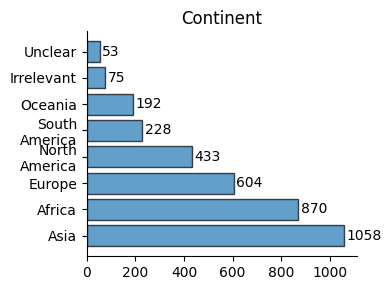

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Convert to a pandas Series for easy sorting and plotting
data_series = pd.Series(c).sort_values(ascending=False)

class_to_label = {
    'ASIA': "Asia",
 'EUROPE': "Europe",
 'NORTH_AMERICA': "North\nAmerica",
 'UNCLEAR': "Unclear",
 'AFRICA': "Africa",
 'SYNTHETIC': "Synthetic",
 'OCEANIA': "Oceania",
 'SOUTH_AMERICA': "South\nAmerica",
 'IRRELEVANT': "Irrelevant",}

# Create the figure and axes
# plt.figure(figsize=(7, 5))
# bars = plt.barh(data_series.index, data_series.values) #, color='skyblue')

# Set title and labels

# plt.xlabel('Proportion', fontsize=12)
# plt.ylabel('Region', fontsize=12)

# Format the x-axis as percentages
# plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))



plt.figure(figsize=(4, 3))
plt.title('Continent', fontsize=12, pad=5)
bars = plt.barh(
    [class_to_label[i] for i in data_series.index], 
    data_series.values,
    edgecolor='black', 
    alpha=0.7
)


# Apply specific styles to "Unclear", "No Data", and "Synthetic"
for bar, label in zip(bars, data_series.index):
    if label in []:#['UNCLEAR', 'SYNTHETIC']:
        bar.set_color('gray')  # Gray out the bars
        bar.set_hatch('//')    # Add a hatch pattern for better distinction

# Add value labels to the end of each bar for clarity
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,  # Position x-coordinate
             bar.get_y() + bar.get_height() / 2,  # Position y-coordinate
             f'{width:}',  # Format as percentage
             ha='left',  # Horizontal alignment
             va='center',  # Vertical alignment
             fontsize=10)

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Ensure the layout is clean
plt.tight_layout()

# Save the plot to a file
plt.savefig("Region_proportions.pdf")

# print("Generated professional_proportions_chart.png")


### Analysis countries by continent

In [21]:
import pandas as pd
df_countries_by_continent = pd.read_csv("Countries by continents.csv", sep=";")
df_countries_by_continent["Continent"] = df_countries_by_continent["Continent"].apply(lambda x : x.upper().replace(" ","_") )

In [22]:
from collections import Counter
import matplotlib.pyplot as plt

def plot_counter_data(counter_data, threshold=5, title="Continent", xlabel="Nation", ylabel="Frequency"):
    """
    Plots a bar chart for a Counter dictionary, grouping smaller values into an "Others" bin.

    Parameters:
        counter_data (Counter): The Counter dictionary to plot.
        threshold (int): The minimum frequency for an item to be displayed individually.
        title (str): The title of the plot.
        xlabel (str): The label for the x-axis.
        ylabel (str): The label for the y-axis.
    """
    # Sort the Counter dictionary by frequency
    sorted_data = counter_data.most_common()

    # Group smaller values into an "Others" bin
    grouped_data = Counter({k: v for k, v in sorted_data if v >= threshold})
    others_count = sum(v for k, v in sorted_data if v < threshold)
    if others_count > 0:
        grouped_data["Others"] = others_count

    # Create the bar plot
    plt.figure(figsize=(6, 4))
    plt.bar(grouped_data.keys(), grouped_data.values(), edgecolor='black', alpha = .7)

    # Add labels and title
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)

    # Display the plot
    plt.tight_layout()
    # plt.show()

In [23]:
from collections import defaultdict

countries_by_cont = defaultdict(list)

for continent in c:
    sub_cbc = df_countries_by_continent[df_countries_by_continent.Continent == continent]
    if continent in ["UNCLEAR","SYNTHETIC"]:
        continue
    df_cont = df_analysis[df_analysis['classification'].apply(lambda x: continent in eval(x))]
    temp = [country for list_countries in  df_cont.countries.values for country in eval(list_countries)]
    countries_by_cont[continent] = [c for c in temp if c in  sub_cbc.Country.values]

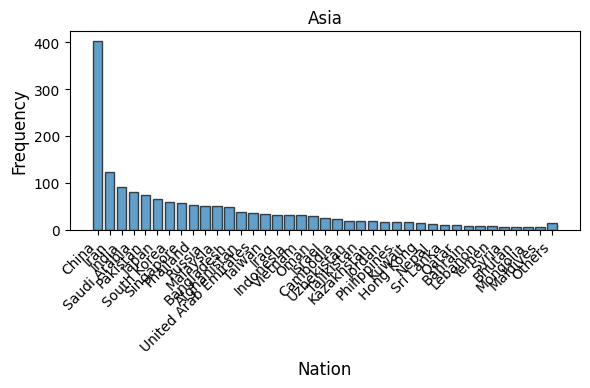

In [24]:
plot_counter_data(Counter(countries_by_cont["ASIA"]), threshold=5)
plt.title("Asia")
plt.savefig("Region_Asia.pdf")

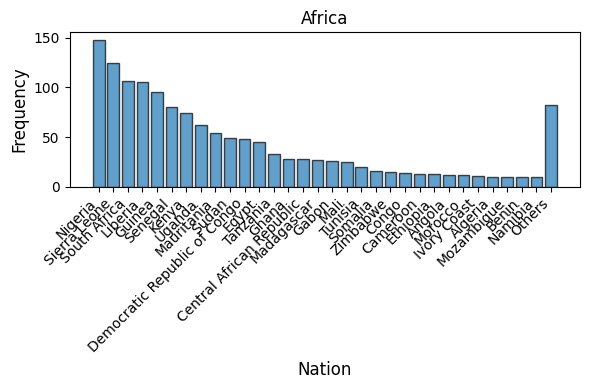

In [31]:
plot_counter_data(Counter(countries_by_cont["AFRICA"]), threshold=10)
plt.title("Africa")
plt.savefig("Region_Africa.pdf")

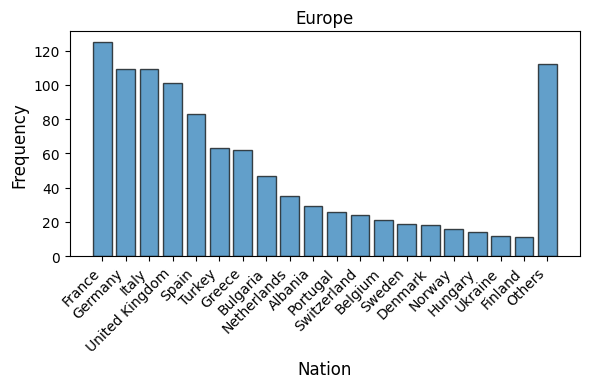

In [30]:
plot_counter_data(Counter(countries_by_cont["EUROPE"]), threshold=10)
plt.title("Europe")
plt.savefig("Region_Europe.pdf")


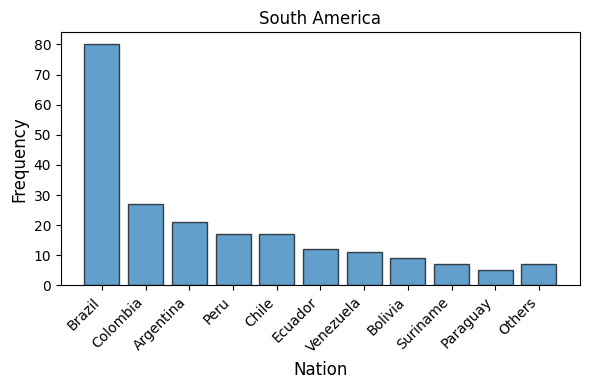

In [27]:
plot_counter_data(Counter(countries_by_cont["SOUTH_AMERICA"]), threshold=5)
plt.title("South America")
plt.savefig("Region_SouthAmerica.pdf")

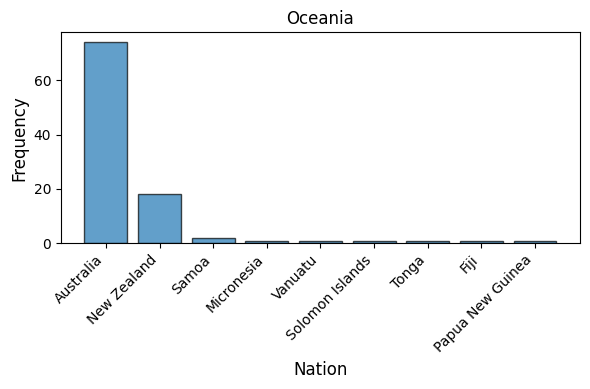

In [28]:
plot_counter_data(Counter(countries_by_cont["OCEANIA"]), threshold=1)
plt.title("Oceania")
plt.savefig("Region_Oceania.pdf")

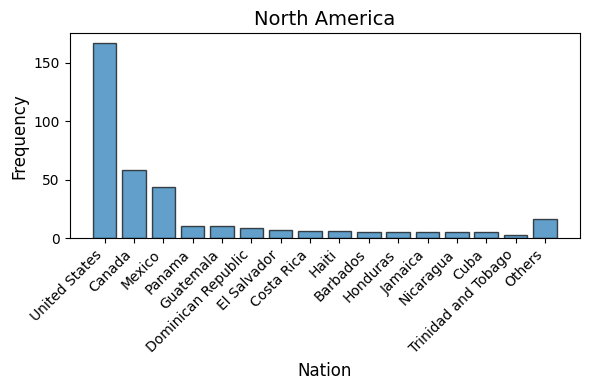

In [29]:
plot_counter_data(Counter(countries_by_cont["NORTH_AMERICA"]), threshold=3,title= "North America")
plt.savefig("Region_NorthAmerica.pdf")
